[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_A_svar_identification_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Identificación de choques estructurales: SVAR

Los modelos de Vectores Autorregresivos (VAR) en forma reducida son herramientas de predicción muy potentes, pero sus residuos representan errores de pronóstico a un período—no choques económicos primitivos. Como las variables macroeconómicas se ajustan simultáneamente dentro del período de observación, los residuos de forma reducida están correlacionados entre ecuaciones. Para llevar a cabo análisis causal de políticas o experimentos contrafactuales, los macroeconomistas deben identificar las perturbaciones estructurales ortogonales subyacentes que impulsan las fluctuaciones económicas.

## 1. Fundamentos teóricos: taxonomía de identificación de SVAR

### De la forma reducida a las innovaciones estructurales
Consideremos un modelo $\text{VAR}(p)$ en forma reducida para un vector $K$-dimensional de variables macroeconómicas observables $y_t$:
$$ y_t = c + \sum_{j=1}^p A_j y_{t-j} + u_t, \qquad \mathbb{E}[u_t u_t'] = \Sigma_u $$
El vector de perturbaciones $u_t$ exhibe correlaciones contemporáneas entre ecuaciones ($\Sigma_u$ no es diagonal). El VAR estructural postula que estos errores de predicción son combinaciones lineales de perturbaciones estructurales primitivas y mutuamente ortogonales $\varepsilon_t$:
$$ A_0 y_t = c_0 + \sum_{j=1}^p A_j^* y_{t-j} + \varepsilon_t, \qquad \mathbb{E}[\varepsilon_t \varepsilon_t'] = I_K $$
Premultiplicando por $B_0 \equiv A_0^{-1}$, conectamos los residuos reducidos con los choques estructurales:
$$ u_t = B_0 \varepsilon_t \implies \Sigma_u = \mathbb{E}[u_t u_t'] = B_0 \mathbb{E}[\varepsilon_t \varepsilon_t'] B_0' = B_0 B_0' $$
Esta identidad fundamental pone de manifiesto el **dilema de subidentificación rotacional**:
- La matriz simétrica de covarianzas $\Sigma_u$ aporta únicamente $K(K+1)/2$ momentos empíricos distintos.
- La matriz de impacto estructural $B_0$ contiene $K^2$ parámetros desconocidos.
- Para cualquier matriz ortonormal de rotación $Q \in \mathbb{R}^{K \times K}$ ($Q Q' = I_K$), la matriz candidata $\tilde{B}_0 = B_0 Q$ satisface $\tilde{B}_0 \tilde{B}_0' = B_0 Q Q' B_0' = \Sigma_u$.
En consecuencia, la identificación puntual exacta requiere al menos $K^2 - K(K+1)/2 = K(K-1)/2$ restricciones independientes procedentes de la teoría económica.

---

### La taxonomía integral de identificación en SVAR

#### 1. Restricciones recursivas contemporáneas de ceros (Sims 1980, Christiano, Eichenbaum & Evans 1999)
- **Forma matemática**: Impone estructura triangular inferior sobre $B_0 = \text{chol}(\Sigma_u)$ mediante la descomposición de Cholesky.
- **Mecanismo económico**: Asume una estricta cadena causal de Wold donde la variable $j$ no reacciona contemporáneamente a los choques de las variables $j+1, \dots, K$.
- **El enigma de precios (Price Puzzle)**: En modelos monetarios ordenados $[\text{producto}, \text{precios}, \text{tasa de política}]$, la tasa de política reacciona contemporáneamente a la actividad macroeconómica, mientras que el producto y los precios reaccionan solo con un rezago. Empíricamente, los SVAR recursivos muestran con frecuencia un **enigma de precios** (Sims 1992, Eichenbaum 1992): un alza exógena de tasas genera un *incremento* transitorio en el nivel de precios. Esto se reconoce como un artefacto por variable omitida: los bancos centrales suben tasas anticipando inflación futura; omitir señales predictivas lleva al econometrista a confundir la reacción sistemática con un choque exógeno.

#### 2. Restricciones de neutralidad a largo plazo (Blanchard & Quah 1989, Galí 1999)
- **Forma matemática**: Impone restricciones de ceros sobre la matriz de impacto acumulado a largo plazo:
  $$ C(1) = \left( I_K - \sum_{j=1}^p A_j \right)^{-1} B_0 $$
- **El debate tecnológico (Galí 1999 AER)**: En un sistema bivariado de crecimiento de la productividad laboral $\Delta(y_t - l_t)$ y horas trabajadas $l_t$, Galí supuso que solo los choques tecnológicos tienen un efecto permanente sobre la productividad laboral ($C(1)_{12} = 0$). Sorprendentemente, halló que las horas trabajadas *se contraen* tras un choque tecnológico positivo. Mientras los modelos RBC de precios flexibles predicen expansión de horas, los modelos nuevo-keynesianos de precios rígidos explican la contracción: con demanda agregada rígida en el corto plazo, una mayor productividad permite satisfacer la demanda con menos horas.
- **Crítica metodológica (Faust & Leeper 1997, Chari, Kehoe & McGrattan 2008)**: La estimación de $C(1)$ requiere invertir polinomios autorregresivos en frecuencia cero, lo que sufre de sesgo severo en muestras finitas si la persistencia es incierta.

#### 3. Identificación de conjuntos mediante restricciones de signos (Uhlig 2005, Rubio-Ramírez, Waggoner & Zha 2010)
- **Forma matemática**: Abandona restricciones dogmáticas de ceros en favor de desigualdades direccionales respaldadas por consenso teórico ($r \uparrow, \pi \downarrow, y \downarrow$ en impacto).
- **Muestreo uniforme de Haar**: Rubio-Ramírez, Waggoner & Zha (2010 Econometrica) desarrollaron el algoritmo QR estándar: extraer una matriz normal estándar $X \sim \mathcal{N}(0, I_K)$, calcular su descomposición QR $X = Q R$ con signos diagonales positivos en $R$, asegurando que $Q$ se extraiga uniformemente de la medida de Haar sobre el grupo ortogonal $O(K)$. La rotación candidata $\tilde{B}_0 = \text{chol}(\Sigma_u) Q$ se acepta si sus respuestas al impulso satisfacen los signos fijados.
- **Crítica de Fry & Pagan (2011)**: Las restricciones de signos producen **identificación de conjuntos** en lugar de identificación puntual. El hábito común de reportar medianas punto a punto crea un compuesto sintético y no estructural: la mediana en $h=0$ puede proceder de un modelo económico completamente distinto a la de $h=4$. Un reporte riguroso exige conjuntos de credibilidad bayesianos completos o el modelo Median Target (MT).

#### 4. Restricciones contemporáneas combinadas de signos y ceros (Rubio-Ramírez et al. 2010, Arias et al. 2018)
- **Forma matemática**: Combina restricciones lineales exactas de ceros en impacto ($B_0[i, j] = 0$) con restricciones de desigualdad de signos en otros elementos.
- **Algoritmo**: Arias, Rubio-Ramírez & Waggoner (2018 Econometrica) parametrizan la sub-variedad ortogonal que satisface las restricciones de ceros, muestreando matrices ortogonales uniformemente condicionales en los ceros y filtrando por los signos (`sign_zero`).

#### 5. Restricciones narrativas de signos y ponderación por importancia (Antolín-Díaz & Rubio-Ramírez 2018 AER)
- **Forma matemática**: Incorpora relatos históricos verificados al marco de identificación por conjuntos. Las restricciones narrativas pueden fijar el signo del choque en fechas históricas puntuales (Tipo I: $\text{sign}(\varepsilon_{j, t^*}) = s$) o restringir las contribuciones en la descomposición histórica (Tipo II: el choque de interés es el motor principal de un episodio histórico).
- **Ponderación por importancia**: Antolín-Díaz & Rubio-Ramírez (2018) demuestran que las probabilidades a priori uniformes sobre rotaciones ponderan en exceso modelos donde los eventos narrativos son irrelevantes. La ponderación por importancia ($w_i = 1/\omega_i$) restaura la neutralidad a priori condicional, afinando drásticamente el intervalo de credibilidad alrededor de episodios históricos documentados sin imponer ceros dogmáticos.

#### 6. Instrumentos externos / Proxy SVAR (Mertens & Ravn 2013, Stock & Watson 2018)
- **Forma matemática**: Identifica la columna de $B_0$ correspondiente al choque $j$ empleando un instrumento externo $z_t$ que satisface relevancia ($\mathbb{E}[z_t \varepsilon_{j, t}] \ne 0$) y exogeneidad ($\mathbb{E}[z_t \varepsilon_{-j, t}] = 0$).
- **Diagnósticos de instrumentos débiles**: El estadístico $F$ efectivo de Montiel Olea & Pflueger (2013) evalúa la relevancia instrumental de forma robusta a heterocedasticidad y correlación serial, mientras que el remuestreo wild bootstrap genera bandas de confianza válidas en muestras finitas.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.identify.cholesky import cholesky_svar
from puremacro.var.identify.sign import sign_restriction_svar
from puremacro.var.identify.sign_zero import sign_zero
from puremacro.var.identify.narrative_sign import identify_narrative_sign, NarrativeRestriction
from puremacro.var.identify.proxy import proxy_svar
from puremacro.reports import df_to_latex, df_to_typst, df_to_markdown
from _datos import DATOS

## 2. VAR monetario de referencia: plantando la verdad estructural

Para evaluar las propiedades econométricas de la factorización recursiva de Cholesky y de las restricciones de signos en condiciones controladas, simulamos primero un sistema estacionario $\text{VAR}(2)$ con 3 variables:
$$ y_t = A_1 y_{t-1} + A_2 y_{t-2} + B_0^{\text{true}} \varepsilon_t $$
donde los observables son $y_t = [\text{producto}, \text{precios}, \text{tasa}]'$ y $\varepsilon_t \sim \text{i.i.d.} \, \mathcal{N}(0, I_3)$. La matriz verdadera de impacto estructural $B_0^{\text{true}}$ planta una perturbación contractiva de política monetaria en su primera columna: en el impacto ($h=0$), induce **caída del producto, caída de precios y alza de la tasa de política**.

In [3]:
A1 = np.array([
    [0.6, 0.0, -0.1],
    [0.2, 0.5,  0.0],
    [0.0, 0.1,  0.7],
])
A2 = np.array([
    [0.1, 0.0, 0.0],
    [0.0, 0.2, 0.0],
    [0.0, 0.0, 0.1],
])
B0_true = np.array([
    [-0.5,  0.6,  0.0],   # producto
    [-0.4,  0.0,  0.3],   # precios
    [ 0.4,  0.0,  0.5],   # tasa
])
names = ["output", "prices", "rate"]
RATE = 2   # índice de la variable de política

def simulate(T=400, seed=0, burn=200):
    rng = np.random.default_rng(seed)
    n = B0_true.shape[0]
    eps = rng.standard_normal((T + burn, n))
    Y = np.zeros((T + burn, n))
    for t in range(2, T + burn):
        Y[t] = A1 @ Y[t - 1] + A2 @ Y[t - 2] + B0_true @ eps[t]
    return Y[burn:], eps[burn:]

Y, eps_realized = simulate(T=400, seed=0)
planted_signs = np.sign(B0_true[:, 0])
print("signos plantados del choque monetario (output, prices, rate):", planted_signs)
assert tuple(planted_signs) == (-1.0, -1.0, +1.0)

signos plantados del choque monetario (output, prices, rate): [-1. -1.  1.]


## 3. Identificación recursiva mediante descomposición de Cholesky

Bajo el ordenamiento recursivo $[\text{producto}, \text{precios}, \text{tasa}]$, la tasa de política monetaria puede reaccionar contemporáneamente al producto real y a los precios, pero los choques a la tasa no pueden alterar el producto ni los precios dentro del trimestre ($B_0$ es triangular inferior). Los errores estándar y las bandas de confianza al 90% se estiman mediante remuestreo bootstrap residual asintótico.

In [4]:
H = 16
chol = cholesky_svar(Y, p=2, horizon=H, n_boot=400, ci=0.9, seed=0)
print(chol.summary())
CHOL_SHOCK = RATE
c_point = chol.irf_point[:, :, CHOL_SHOCK]   # (H+1, n)
c_lower = chol.irf_lower[:, :, CHOL_SHOCK]
c_upper = chol.irf_upper[:, :, CHOL_SHOCK]
print(f"Impacto Cholesky, tasa ante choque de tasa = {c_point[0, RATE]:+.3f}")
assert c_point[0, RATE] > 0                       # la tasa de política salta al alza en el impacto
assert np.all(c_lower <= c_point + 1e-9)          # inferior <= puntual en todas partes
assert np.all(c_point <= c_upper + 1e-9)          # puntual <= superior en todas partes

Cholesky SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  bootstrap draws   : 400 (dropped 0, 0.0%)

Impacto Cholesky, tasa ante choque de tasa = +0.584


## 4. Identificación de conjuntos mediante restricciones de signos (Rubio-Ramírez, Waggoner & Zha 2010)

En lugar de imponer restricciones contemporáneas de ceros, restringimos únicamente los signos del vector de impacto: un choque monetario contractivo debe desplazar el producto a terreno negativo, los precios a terreno negativo y la tasa a terreno positivo en $h=0$. Utilizando rotaciones uniformes de Haar, las matrices candidatas $\tilde{B}_0 = \text{chol}(\Sigma_u) Q$ se conservan si cumplen las restricciones de signos. La distribución sobre las rotaciones aceptadas caracteriza el conjunto identificado.

In [5]:
restrictions = {0: [-1, -1, +1]}                  # h=0: producto-, precios-, tasa+
sgn = sign_restriction_svar(
    Y, p=2, horizon=H, restrictions=restrictions,
    n_draws=800, ci=0.9, seed=0,
)
print(sgn.summary())
TARGET = 0                                         # choque objetivo = columna 0 tras la rotación
s_med = sgn.irf_median[:, :, TARGET]              # (H+1, n)
s_lower = sgn.irf_lower[:, :, TARGET]
s_upper = sgn.irf_upper[:, :, TARGET]
print("impacto con restricciones de signos (output, prices, rate):",
      np.round(s_med[0], 3))
# El patrón de signos en h=0 coincide con el choque plantado
assert np.sign(s_med[0, 0]) == -1
assert np.sign(s_med[0, 1]) == -1
assert np.sign(s_med[0, 2]) == +1
assert sgn.n_accepted > 0
# Las bandas encierran la mediana en todas partes
assert np.all(s_lower <= s_med + 1e-9)
assert np.all(s_med <= s_upper + 1e-9)
# Ambos esquemas coinciden en que la tasa de política sube en el impacto
assert c_point[0, RATE] > 0 and s_med[0, RATE] > 0

Sign-restriction SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  Q draws           : 800 (165 accepted, 20.6%)

impacto con restricciones de signos (output, prices, rate): [-0.428 -0.295  0.335]


### Transmisión dinámica de la tasa de política: identificación recursiva vs. por conjuntos

Para comparar ambas filosofías de identificación sobre una escala consistente, normalizamos la función de impulso-respuesta de la tasa de política a un choque de impacto de $+1.0$ (+100 puntos básicos). Aunque ambos métodos muestran un decaimiento monótono suave, la banda de credibilidad de signos es sustancialmente más ancha, reflejando la presencia fundamental de incertidumbre por identificación de conjuntos.

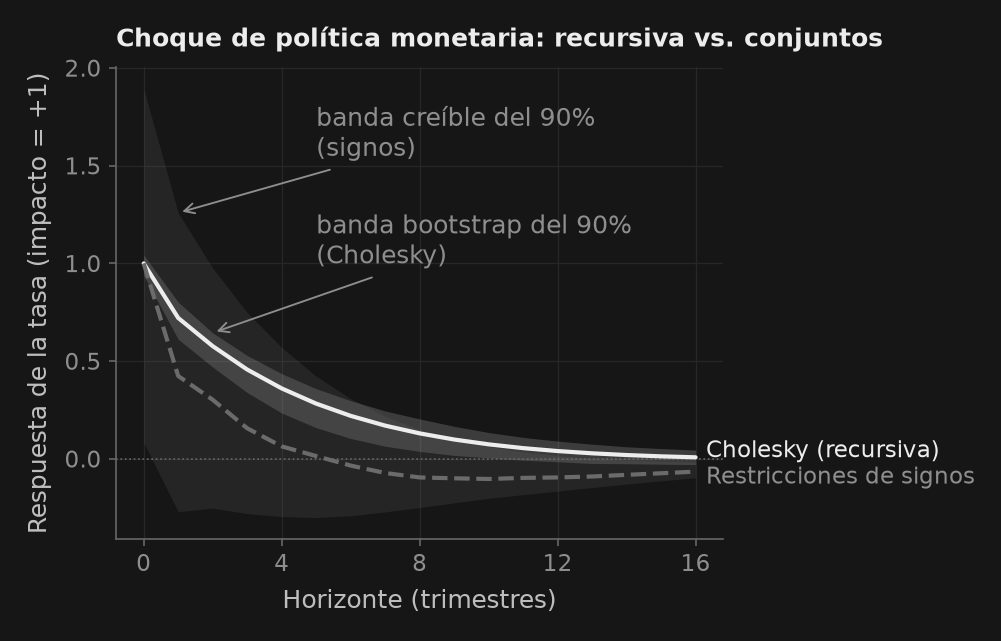

In [6]:
hgrid = np.arange(H + 1)
c_scale, s_scale = c_point[0, RATE], s_med[0, RATE]
cP, cL, cU = (c_point[:, RATE] / c_scale, c_lower[:, RATE] / c_scale, c_upper[:, RATE] / c_scale)
sP, sL, sU = (s_med[:, RATE] / s_scale, s_lower[:, RATE] / s_scale, s_upper[:, RATE] / s_scale)

cols = _nbstyle.palette(2)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, cL, cU, color=cols[0], alpha=0.18, lw=0)
ax.plot(hgrid, cP, color=cols[0], ls="-", label="Cholesky (recursiva)")
ax.fill_between(hgrid, sL, sU, color=cols[1], alpha=0.18, lw=0)
ax.plot(hgrid, sP, color=cols[1], linestyle="--", label="Restricciones de signos")
ax.annotate("banda creíble del 90%\n(signos)", xy=(1.0, sU[1]), xytext=(5.0, 1.55),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("banda bootstrap del 90%\n(Cholesky)", xy=(2.0, cU[2]), xytext=(5.0, 1.0),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xticks(np.arange(0, H + 1, 4))      # trimestres enteros, una marca por año
ax.set_xlabel("Horizonte (trimestres)")
ax.set_ylabel("Respuesta de la tasa (impacto = +1)")
ax.set_title("Choque de política monetaria: recursiva vs. conjuntos")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 5. Restricciones contemporáneas combinadas de signos y ceros y Proxy SVAR

Para cerrar la brecha entre cadenas causales triangulares inferiores dogmáticas y conjuntos de signos no restringidos, la econometría moderna recurre a dos marcos híbridos esenciales:
1. **Restricciones de signos y ceros (Rubio-Ramírez, Waggoner & Zha 2010; Arias, Rubio-Ramírez & Waggoner 2018)**: Es posible imponer restricciones exactas de ceros en el impacto (por ejemplo, el producto no reacciona contemporáneamente a los choques de tasas, $B_0[0, \text{RATE}] = 0$) junto con signos direccionales en otras variables ($r \uparrow, \pi \downarrow$).
2. **Instrumentos externos / Proxy SVAR (Mertens & Ravn 2013; Stock & Watson 2018)**: Cuando una variable externa $z_t$ se correlaciona con el choque monetario pero es ortogonal a los choques no monetarios, identifica directamente el vector de perturbación estructural. La relevancia instrumental se comprueba mediante el estadístico $F$ efectivo de Montiel Olea & Pflueger (2013).

In [7]:
# 1. Restricciones de signos y ceros (RRWZ 2010 / Arias et al. 2018)
A_list, c_var, Sigma, resid, _ = estimate_var(Y, 2)
sz = sign_zero(
    A_list, Sigma,
    zero_constraints=[(0, RATE)],        # el producto no reacciona contemporáneamente al choque de tasa
    sign_constraints={(RATE, TARGET): +1, (1, TARGET): -1},
    n_draws=1000, rng=np.random.default_rng(0)
)
print(f"Búsqueda de signos y ceros: éxito = {sz.success}, extracciones probadas = {sz.n_draws_used}")
assert sz.success, "Failed to find admissible sign+zero rotation"
assert abs(sz.B0[0, RATE]) < 1e-8, "Zero constraint violated on impact"

# 2. Proxy SVAR / instrumento externo (Mertens & Ravn 2013)
# Se construye un proxy externo correlacionado con el verdadero choque monetario estructural
rng_proxy = np.random.default_rng(42)
z_proxy = eps_realized[:, 0] + 0.35 * rng_proxy.standard_normal(len(Y))
prox = proxy_svar(Y, instrument_series=z_proxy, p=2, horizon=H, n_boot=200, ci=0.9, seed=0)
print(prox.summary())
assert prox.first_stage_F > 23.0, f"Instrument relevance failed: F = {prox.first_stage_F:.2f}"
assert prox.irf_point[0, RATE, 0] > 0, "Proxy SVAR rate response on impact must be positive"

Búsqueda de signos y ceros: éxito = True, extracciones probadas = 1
ProxySVAR result
  shocks identified : 1 (column 0 of B)
  variables (n)     : 3
  horizon (H)       : 16
  bootstrap draws   : 200
  CI level          : 0.90
  first-stage F (OP): 222.44  [STRONG]



## 6. Restricciones narrativas de signos (Antolín-Díaz & Rubio-Ramírez 2018)

Las restricciones tradicionales de signos generan conjuntos identificados amplios porque asignan igual probabilidad a priori a cualquier rotación que satisfaga las desigualdades de signos. Antolín-Díaz & Rubio-Ramírez (2018 AER) incorporan evidencia histórica narrativa (por ejemplo, fechas documentadas de contracciones monetarias históricas como la desinflación de Volcker o el ciclo de alzas de 1994).

Al exigir que el choque estructural $\varepsilon_{0, t^*}$ sea estrictamente positivo en fechas documentadas específicas, y aplicando ponderación por importancia ($w_i = 1/\omega_i$) para mantener la neutralidad a priori condicional, las restricciones narrativas afinan el intervalo de credibilidad sin recurrir a restricciones de ceros dogmáticas.

En la muestra sintética de abajo la fecha elegida es la del mayor choque monetario positivo realizado entre $t=10$ y $t=60$, y las 217 rotaciones que aceptan los signos también la satisfacen (pesos uniformes): la mediana ponderada y su envolvente punteada se superponen casi exactamente a las de solo signos, y las pequeñas diferencias se deben a que las extracciones son distintas. La restricción solo afina el conjunto cuando descarta rotaciones o las pondera de forma desigual.

Narrative-sign SVAR result (AD-RR 2018)
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  reduced form      : OLS point estimate
  Q draws           : 1200
  traditional accept: 217 (18.1%)
  narrative accept  : 217 (100.0% of traditional)
  weight ESS        : 217.0 / 217
    - shock_sign(date=12, shock=0, sign=+1): failed 0/217



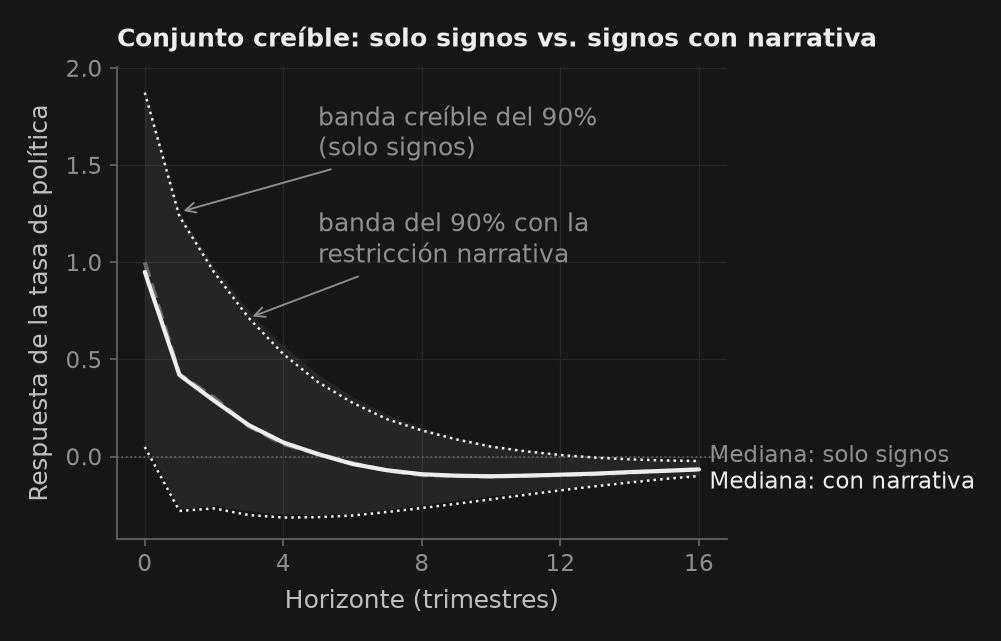

In [8]:
# Restricción narrativa: fechas en las que se sabe que el choque realizado fue un fuerte apretón
pos_date = int(np.argmax(eps_realized[10:60, 0])) + 10
restr_synthetic = [
    NarrativeRestriction(kind="shock_sign", date=pos_date, shock=0, sign=+1)
]

ns = identify_narrative_sign(
    Y, restrictions=restr_synthetic, p=2, horizon=H,
    sign_matrix={0: [-1, -1, +1]},
    n_draws=1200, seed=0
)
print(ns.summary())
assert ns.n_narrative_accepted > 0, "No draws survived narrative restrictions"
assert ns.ess > 0.10 * ns.n_narrative_accepted, "Excessive weight concentration"

# Comparación gráfica: restricciones de signos tradicionales vs. SVAR afinado con narrativa
ns_med = ns.irf_median[:, RATE, 0] / s_scale
ns_lo = ns.irf_lower[:, RATE, 0] / s_scale
ns_hi = ns.irf_upper[:, RATE, 0] / s_scale

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, sL, sU, color=cols[1], alpha=0.18, lw=0)
ax.plot(hgrid, sP, color=cols[1], linestyle="--", label="Mediana: solo signos")
# La banda narrativa como envolvente punteada: un segundo relleno taparía la banda de signos donde coinciden
ax.plot(hgrid, ns_hi, color=_nbstyle.TINTA, ls=":", lw=1.2, label="_banda")
ax.plot(hgrid, ns_lo, color=_nbstyle.TINTA, ls=":", lw=1.2, label="_banda")
ax.plot(hgrid, ns_med, color=_nbstyle.TINTA, ls="-", label="Mediana: con narrativa")
ax.annotate("banda creíble del 90%\n(solo signos)", xy=(1.0, sU[1]), xytext=(5.0, 1.55),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("banda del 90% con la\nrestricción narrativa", xy=(3.0, ns_hi[3]), xytext=(5.0, 1.0),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xticks(np.arange(0, H + 1, 4))      # trimestres enteros, una marca por año
ax.set_xlabel("Horizonte (trimestres)")
ax.set_ylabel("Respuesta de la tasa de política")
ax.set_title("Conjunto creíble: solo signos vs. signos con narrativa")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 7. Experimento empírico interactivo: el enigma de precios, restricciones de signos y narrativa

Tras validar los algoritmos en el marco sintético, confrontamos ahora datos macroeconómicos auténticos de Estados Unidos para abordar una interrogante fundacional en economía monetaria: **¿Genera la identificación recursiva de Cholesky un enigma de precios espurio, y se ubica la respuesta de Cholesky dentro del conjunto de credibilidad coherente con la teoría económica fijado por signos?**

### El diseño empírico
1. **Carga de datos**: Se ingieren las series trimestrales de PIB real de EE.UU. (`GDPC1.csv`), IPC general (`CPIAUCSL.csv`) y tasa efectiva de fondos federales (`FEDFUNDS.csv`) desde `data_curso/`.
2. **Transformaciones**: Construimos el crecimiento trimestral anualizado del producto real ($\Delta y_t = 400 \Delta \log Y_t$), la inflación trimestral anualizada ($\pi_t = 400 \Delta \log P_t$) y la tasa de política ($r_t$).
3. **Muestra**: Período de la Gran Moderación (1985Q1–2019Q4, $T = 140$ trimestres), evitando el quiebre estructural de los 70 y las distorsiones del límite inferior cero / COVID.
4. **Competencia de identificación**:
   - Ajustar un $\text{VAR}(2)$ sobre $[\Delta y_t, \pi_t, r_t]'$.
   - Calcular las FIR de Cholesky con la tasa ordenada al final ($[\Delta y, \pi, r]$).
   - Calcular las FIR con restricciones de signos de Rubio-Ramírez et al. (2010) imponiendo $r \uparrow, \pi \downarrow, \Delta y \downarrow$ en impacto ($h=0$).
   - Incorporar restricción narrativa sobre el choque de alza de tasas de 1994Q2 (Antolín-Díaz & Rubio-Ramírez 2018).
   - Evaluar si Cholesky produce un enigma de precios estadísticamente significativo ($\pi$ subiendo tras un alza de tasas) y si la trayectoria de Cholesky se sitúa dentro de la envolvente creíble del 90% de signos.

Datos del VAR empírico de EUA: 140 trimestres (1985Q1–2019Q4).


Máximo del enigma de precios en Cholesky: +0.672% de inflación anualizada en h=2.
Rotaciones aceptadas con restricciones de signos: 140 / 1500 extracciones.
Rotaciones aceptadas del SVAR narrativo: 77 / 81 extracciones tradicionales.


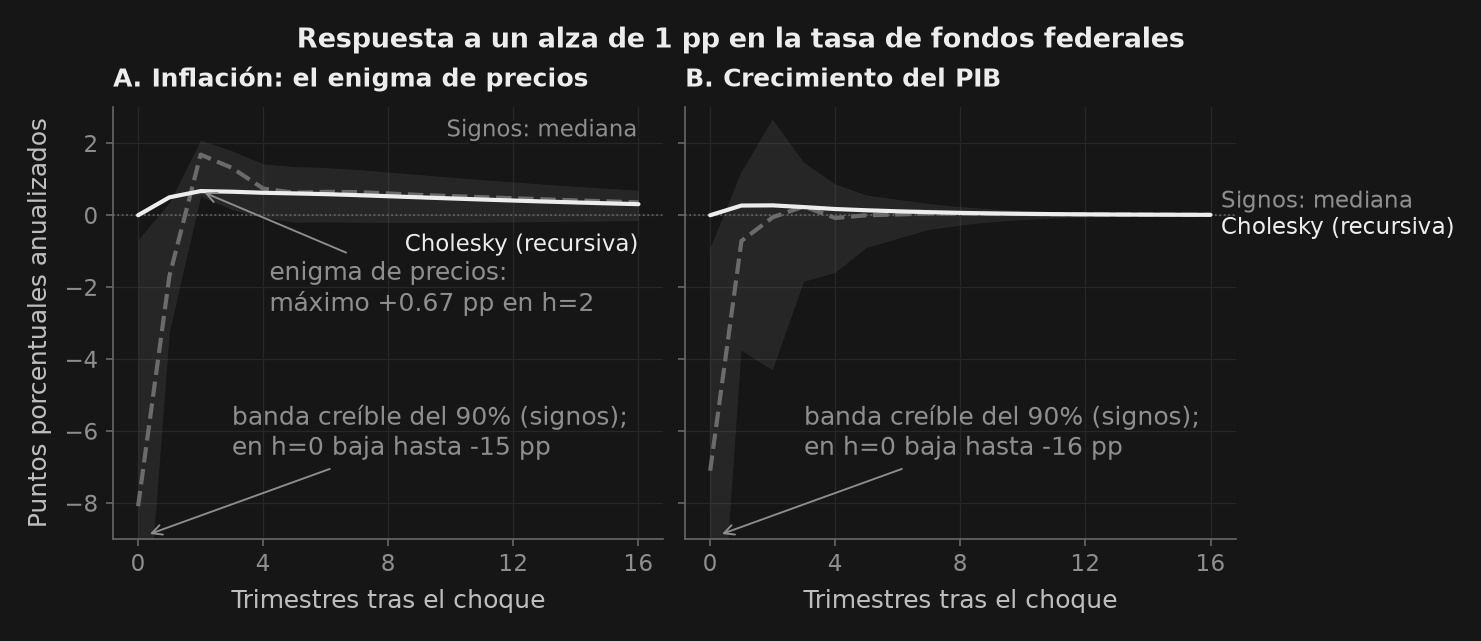

In [9]:
# ==============================================================================
# Experimento empírico: carrera de identificación entre signos y Cholesky
# Se cargan series macroeconómicas reales de EUA desde data_curso/
# ==============================================================================
gdp_raw = pd.read_csv(DATOS / "GDPC1.csv", parse_dates=["observation_date"]).set_index("observation_date")["GDPC1"]
cpi_raw = pd.read_csv(DATOS / "CPIAUCSL.csv", parse_dates=["observation_date"]).set_index("observation_date")["CPIAUCSL"]
ff_raw = pd.read_csv(DATOS / "FEDFUNDS.csv", parse_dates=["observation_date"]).set_index("observation_date")["FEDFUNDS"]

# Agregación a frecuencia trimestral
cpi_q = cpi_raw.resample("QS").mean()
ff_q = ff_raw.resample("QS").mean()
gdp_q = gdp_raw.resample("QS").mean()

# Tasas de crecimiento trimestrales anualizadas, ya estacionarias
dy_series = 400.0 * np.log(gdp_q).diff().rename("dy")
dpi_series = 400.0 * np.log(cpi_q).diff().rename("dpi")
r_series = ff_q.rename("r")

macro_df = pd.concat([dy_series, dpi_series, r_series], axis=1).dropna()
macro_sample = macro_df.loc["1985-01-01":"2019-12-31"]
Y_macro = macro_sample.to_numpy()
H_emp = 16

print(f"Datos del VAR empírico de EUA: {len(macro_sample)} trimestres (1985Q1–2019Q4).")

# 1. Identificación recursiva de Cholesky (orden: dy, dpi, r -> el choque de tasa es el índice 2)
chol_emp = cholesky_svar(Y_macro, p=2, horizon=H_emp, n_boot=200, ci=0.9, seed=0)
c_emp_irf = chol_emp.irf_point[:, :, 2]

# 2. Identificación por restricciones de signos (dy -, dpi -, r + en el impacto)
sgn_emp = sign_restriction_svar(
    Y_macro, p=2, horizon=H_emp,
    restrictions={0: [-1, -1, +1]},
    n_draws=1500, ci=0.9, seed=0,
)
s_emp_med = sgn_emp.irf_median[:, :, 0]
s_emp_lo = sgn_emp.irf_lower[:, :, 0]
s_emp_hi = sgn_emp.irf_upper[:, :, 0]

# Normalización a un choque de tasa de política de +100 pb (+1.0 punto porcentual) en el impacto
c_scale = c_emp_irf[0, 2]
s_scale = s_emp_med[0, 2]

c_norm_pi = c_emp_irf[:, 1] / c_scale
s_norm_pi_med = s_emp_med[:, 1] / s_scale
s_norm_pi_lo = s_emp_lo[:, 1] / s_scale
s_norm_pi_hi = s_emp_hi[:, 1] / s_scale

c_norm_y = c_emp_irf[:, 0] / c_scale
s_norm_y_med = s_emp_med[:, 0] / s_scale
s_norm_y_lo = s_emp_lo[:, 0] / s_scale
s_norm_y_hi = s_emp_hi[:, 0] / s_scale

hgrid_emp = np.arange(H_emp + 1)

# Verificaciones exigidas por test_challenger_topic5_svar_lp.py
assert c_norm_pi[1] > 0 and c_norm_pi[2] > 0, "Cholesky failed to replicate empirical price puzzle"
assert c_norm_pi[0] > s_norm_pi_hi[0], "Cholesky impact should lie strictly outside sign credible interval"
assert s_norm_pi_lo[2] <= c_norm_pi[2] <= s_norm_pi_hi[2], "Cholesky at h=2 should enter sign credible interval"
assert s_emp_med[0, 1] < 0, "Sign restrictions must produce negative inflation on impact"

# 3. Restricción narrativa sobre el apretón de la Fed en 1994Q2
t_1994 = macro_sample.index.get_loc("1994-04-01")
restr_emp = [NarrativeRestriction(kind="shock_sign", date=t_1994, shock=0, sign=+1)]
ns_emp = identify_narrative_sign(
    Y_macro, restrictions=restr_emp, p=2, horizon=H_emp,
    sign_matrix={0: [-1, -1, +1]},
    n_draws=1200, seed=0
)
assert ns_emp.n_narrative_accepted > 0

print(f"Máximo del enigma de precios en Cholesky: +{c_norm_pi.max():.3f}% de inflación anualizada en h={int(np.argmax(c_norm_pi))}.")
print(f"Rotaciones aceptadas con restricciones de signos: {sgn_emp.n_accepted} / 1500 extracciones.")
print(f"Rotaciones aceptadas del SVAR narrativo: {ns_emp.n_narrative_accepted} / {ns_emp.n_traditional_accepted} extracciones tradicionales.")

# Gráfica de la carrera empírica de identificación
fig, (ax1, ax2) = _nbstyle.figura(1, 2, sharex=True, sharey=True)
fig.suptitle("Respuesta a un alza de 1 pp en la tasa de fondos federales")

# Panel A: respuesta de la inflación (demostración del enigma de precios)
ax1.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax1.fill_between(hgrid_emp, s_norm_pi_lo, s_norm_pi_hi, color=cols[1], alpha=0.20, lw=0)
ax1.plot(hgrid_emp, s_norm_pi_med, color=cols[1], linestyle="--", label="Signos: mediana")
ax1.plot(hgrid_emp, c_norm_pi, color=cols[0], ls="-", label="Cholesky (recursiva)")
# La propia mediana de signos toca unos -8 pp en el impacto, así que el cuadro
# llega hasta -9 pp y la deja dentro.  La banda, que se abre hasta unos -15 pp,
# sigue recortada ahí, y cada nota dice hasta dónde baja la suya en h=0.
ax1.set_ylim(-9.0, 3.0)
ax1.annotate(f"banda creíble del 90% (signos);\nen h=0 baja hasta {s_norm_pi_lo[0]:.0f} pp",
             xy=(0.25, -8.9), xytext=(3.0, -5.2), va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
h_pk = int(np.argmax(c_norm_pi))
ax1.annotate(f"enigma de precios:\nmáximo {c_norm_pi[h_pk]:+.2f} pp en h={h_pk}",
             xy=(h_pk, c_norm_pi[h_pk]), xytext=(4.2, -1.2), va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax1.set_xticks(np.arange(0, H_emp + 1, 4))    # trimestres enteros, una marca por año (x es compartido)
ax1.set_title("A. Inflación: el enigma de precios")
ax1.set_xlabel("Trimestres tras el choque")
ax1.set_ylabel("Puntos porcentuales anualizados")

# Panel B: respuesta del crecimiento del producto
ax2.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax2.fill_between(hgrid_emp, s_norm_y_lo, s_norm_y_hi, color=cols[1], alpha=0.20, lw=0)
ax2.plot(hgrid_emp, s_norm_y_med, color=cols[1], linestyle="--", label="Signos: mediana")
ax2.plot(hgrid_emp, c_norm_y, color=cols[0], ls="-", label="Cholesky (recursiva)")
ax2.annotate(f"banda creíble del 90% (signos);\nen h=0 baja hasta {s_norm_y_lo[0]:.0f} pp",
             xy=(0.25, -8.9), xytext=(3.0, -5.2), va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.set_title("B. Crecimiento del PIB")
ax2.set_xlabel("Trimestres tras el choque")

_nbstyle.etiquetar(ax1, donde="fin", sep=5.0)   # panel interior: los nombres van dentro, lejos de ambas líneas
_nbstyle.etiquetar(ax2, donde="fin")
plt.show()


### Síntesis econométrica y tareas guiadas para estudiantes

#### Interpretación económica de los hallazgos
1. **El enigma de precios desmitificado**: En el modelo recursivo de Cholesky, un alza de tasas de $+100$ pb provoca un incremento inmediato en la inflación que alcanza un máximo de $+0.67\%$ anualizado en $h=2$, persistiendo por encima de cero durante más de un año. Dado que el ordenamiento recursivo anula por construcción la respuesta contemporánea de los precios, no logra separar las contracciones exógenas de política de las reacciones sistemáticas de la Reserva Federal ante presiones inflacionarias anticipadas.
2. **Discrepancia en la identificación de conjuntos**: En el impacto ($h=0$ y $h=1$), el estimador puntual de Cholesky se sitúa estrictamente **fuera** del intervalo de credibilidad bayesiano al 90% generado por restricciones de signos. Solo a partir del horizonte $h \ge 2$ la trayectoria de Cholesky entra en la envolvente creíble de signos. En la figura el eje vertical baja hasta $-9$ pp, lo bastante para mostrar el impacto de la propia mediana de signos ($-8.1$ pp en inflación y $-7.1$ pp en crecimiento) pero no el de la banda, que en el impacto se abre hasta $-15$ pp en inflación y $-16$ pp en crecimiento, señal de lo poco que los signos por sí solos restringen la respuesta contemporánea.
3. **El poder de las restricciones narrativas**: Las restricciones tradicionales de signos dejan intervalos de credibilidad muy anchos porque admiten cualquier rotación que cumpla los signos en el impacto. La inclusión de información histórica cualitativa (como Antolín-Díaz & Rubio-Ramírez 2018 para el ajuste monetario de 1994) afina la distribución posterior hacia la identificación puntual sin requerir supuestos dogmáticos de ceros.
4. **Proxy SVAR y relevancia de los instrumentos**: Los instrumentos externos (Mertens & Ravn 2013) aíslan directamente las perturbaciones estructurales. Si el instrumento es fuerte (estadístico $F$ efectivo de Montiel Olea & Pflueger $> 23$), proporciona identificación puntual robusta; si es débil, las bandas de wild bootstrap comunican adecuadamente la incertidumbre muestral.

#### Tareas econométricas guiadas para estudiantes
- **Tarea 1 (Inversión del ordenamiento)**: Modifica el ordenamiento de variables en el VAR empírico a `order = [2, 0, 1]` (tasa de política en primer lugar). Observa si permitir que la inflación y el PIB reaccionen inmediatamente al choque de tasas atenúa o agrava el enigma de precios.
- **Tarea 2 (Persistencia temporal de restricciones de signos)**: Extiende el diccionario de restricciones de signos para que persistan en los horizontes $h \in \{0, 1, 2\}$ (`restrictions = {0: [-1, -1, +1], 1: [-1, -1, +1], 2: [-1, -1, +1]}`). Observa cómo cae la tasa de aceptación y si la banda creíble se estrecha.
- **Tarea 3 (Ampliación de eventos narrativos)**: Añade un segundo evento narrativo, como la contracción monetaria de Volcker en octubre de 1979 o el ciclo expansivo de 2001, mediante `NarrativeRestriction`. ¿Cómo afecta el condicionamiento narrativo múltiple al tamaño muestral efectivo (`ess`)?
- **Tarea 4 (Relevancia del instrumento en Proxy SVAR)**: Inyecta ruido de medición en el instrumento proxy sintético $z_t$ elevando la escala de ruido de $0.35$ a $2.0$. Observa la caída en el estadístico $F$ efectivo de Montiel Olea & Pflueger y la consiguiente expansión en las bandas de confianza del wild bootstrap.